<a href="https://colab.research.google.com/github/readytocommit/DeepLearning--MIT-Series/blob/main/music_classification_MIT_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#Set the seed

keras.utils.set_random_seed(42)

In [2]:
#STIE Process ..

# Standardization
# Tokenization
# Indexing
# Encoding

# Implented by TextVectorization Layer of layers in keras, We just have to specify output_mode,standaradalize and split

text_vectorization = keras.layers.TextVectorization(
    output_mode = 'multi_hot',
    standardize = 'lower_and_strip_punctuation',
    split = 'whitespace'
)

In [3]:
#Now that the layer has been configured, we have to run it on a bunch of text to populate it

# Use adapt() method for this

dataset = ["I write, erase, rewrite",
           "Erase again, and then",
           "A poppy blooms.",
           "Hola! are you laid-back in Mexico" ]

#Index vocabulary of the text
text_vectorization.adapt(dataset)

# Use get_vocabulary() to see what exactly has been done
vocabs = text_vectorization.get_vocabulary()


In [7]:
vocabs

['[UNK]',
 np.str_('erase'),
 np.str_('you'),
 np.str_('write'),
 np.str_('then'),
 np.str_('rewrite'),
 np.str_('poppy'),
 np.str_('mexico'),
 np.str_('laidback'),
 np.str_('in'),
 np.str_('i'),
 np.str_('hola'),
 np.str_('blooms'),
 np.str_('are'),
 np.str_('and'),
 np.str_('again'),
 np.str_('a')]

In [8]:
#Note that the integer0 is assigned to Unk token. When the model is used for prediction, it may be fed a word thats not present in the
# vocabulary. The unk token will be used to represent such words.

#Now that we have configured and populated the TextVectorization layer, we can run any sentence through it easily.

In [9]:
#Encode and decode an example sentence

test_sentence = "I write, rewrite, and still rewrite again"
encode_sentence = text_vectorization(test_sentence)

print(encode_sentence)

tf.Tensor([1 0 0 1 0 1 0 0 0 0 1 0 0 0 1 1 0], shape=(17,), dtype=int64)


In [10]:
#It is a 0-1 vector that is as long as our vocabulary (i.e 17)
# Recall the UNK token is at index 0 and the encoded sentence does have a 1 in that position.

#beacuse of the still. It is not in its vocabulary.

"still" in vocabs

False

In [11]:
#Text_vectorization("Sloan,HODL,DMD") will be represented as ?

text_vectorization("Soan,HODL,DMD")

<tf.Tensor: shape=(17,), dtype=int64, numpy=array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])>

In [12]:
#Yes obvious, all these words are unknown to the vocabs. So the encoding is multihot, so it picks up a only 1 at the unknown position

In [5]:
#Retrieving and Preparing the Data

train_url = "https://www.dropbox.com/scl/fi/ito6bnl2yaf1uw0uqibzf/lyric_genre_train.csv?rlkey=04dkn5un2djza8x0bdmfnlw3u&st=y47qh8i4&dl=1"
val_url = "https://www.dropbox.com/scl/fi/xmywjzqsaa8n5sn1bs0t9/lyric_genre_val.csv?rlkey=hggbeo0s1iaxjpa6z80429xl9&st=6i7d8eau&dl=1"
test_url = "https://www.dropbox.com/scl/fi/fnocl69w9ojs9s5zb0xvf/lyric_genre_test.csv?rlkey=z4hjopw7vaihoh948cbb5mvdp&st=xwond7dp&dl=1"

train_df = pd.read_csv(train_url, index_col=0)
validation_df = pd.read_csv(val_url, index_col=0)
test_df = pd.read_csv(test_url, index_col=0)


In [14]:
print(f"""
Train samples: {train_df.shape[0]}
Validation Samples : {validation_df.shape[0]}
Test Samples: {test_df.shape[0]}

""")


Train samples: 48991
Validation Samples : 16331
Test Samples: 21774




In [15]:
train_df.head()

,Lyric,Genre
0,"Oh, girl. I can't get ready (Can't get ready f...",Pop
1,We met on a rainy evening in the summertime. D...,Pop
2,We carried you in our arms. On Independence Da...,Rock
3,I know he loved you. A long time ago. I ain't ...,Pop
4,Paralysis through analysis. Yellow moral uncle...,Rock


In [16]:
#Checking the proportion of each

train_df['Genre'].value_counts() / train_df.shape[0]

,count
Genre,
Rock,0.549448
Pop,0.295136
Hip Hop,0.155416


In [6]:
#The genre column should be one hot encoded to feed in the neural_network

y_train = pd.get_dummies(train_df['Genre']).to_numpy()
y_val = pd.get_dummies(validation_df['Genre']).to_numpy()
y_test = pd.get_dummies(test_df['Genre']).to_numpy()

print(y_test.shape)

(21774, 3)


In [18]:
y_train.shape

(48991, 3)

In [19]:
#Baseline Model(Bag off Words)

#We will begin by building the simplest model we would come up with:

# We will tokenize at a word level, and each token will be exactly one word (unigram)
# We will use the one-hot encoding that converts each token into a binary vector indicating the presence of the token. Note that when
# we tokenize at a word level and use a one-hot-encoding to indicate the presence (or as we will see later, the count of the word), the model
# is called bag of words.
# max_tokens defines the size of vocabulary the layer is allowed to construct. If the number of tokens in the adapt dataset exceeds this number,
# the layer will choose the max_tokens most frequent tokens and ignore the rest.



In [20]:
#First, we set up our Text Vectorization layer using multi-hot encoding

max_tokens = 5000
text_vectorization = keras.layers.TextVectorization(
    max_tokens = max_tokens,
    output_mode = "multi_hot"
)

In [21]:
#Now let's run our STIE process on the training corpus

# The vocabulary that will be indexed is given by the text corpus on our train dataset.

text_vectorization.adapt(train_df['Lyric'])

In [22]:
#Lets look at the 20 most and 20 least common words in our vectorizytion.

text_vectorization.get_vocabulary()[:20]

['[UNK]',
 np.str_('the'),
 np.str_('you'),
 np.str_('i'),
 np.str_('to'),
 np.str_('and'),
 np.str_('a'),
 np.str_('me'),
 np.str_('it'),
 np.str_('my'),
 np.str_('in'),
 np.str_('im'),
 np.str_('on'),
 np.str_('your'),
 np.str_('that'),
 np.str_('of'),
 np.str_('all'),
 np.str_('be'),
 np.str_('is'),
 np.str_('we')]

In [23]:
text_vectorization.get_vocabulary()[-20:]

[np.str_('eden'),
 np.str_('dagger'),
 np.str_('curve'),
 np.str_('cheddar'),
 np.str_('brew'),
 np.str_('appears'),
 np.str_('vacant'),
 np.str_('universal'),
 np.str_('unholy'),
 np.str_('terrified'),
 np.str_('stickin'),
 np.str_('rumble'),
 np.str_('rug'),
 np.str_('pam'),
 np.str_('os'),
 np.str_('ooohh'),
 np.str_('motto'),
 np.str_('marshall'),
 np.str_('loyalty'),
 np.str_('legacy')]

In [24]:
# Then we vectorize our input

x_train = text_vectorization(train_df['Lyric'])
x_val = text_vectorization(validation_df['Lyric'])
x_test = text_vectorization(test_df['Lyric'])




In [25]:
print(x_train[1])

tf.Tensor([1 1 1 ... 0 0 0], shape=(5000,), dtype=int64)


In [26]:
# We can think of this matrix as a sequence of row vectors. Each row vector us one of the ~49k songs in our training data, and each entry of this
# vector indicates the presence of the word that is indexed in that position. For example, the second  entry in all the vectors corresponds to the
# word 'the' and a 1 indicates th presence o

In [27]:
# Let's try a simple 1-hidden layer NN with just 8 neurons in the hidden layer.

inputs = keras.Input(shape = (max_tokens,))
x = keras.layers.Dense(8,activation="relu")(inputs)
output = keras.layers.Dense(3,activation="softmax")(x)

model = keras.Model(inputs,output)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        40,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,035 (156.39 KB)

 Trainable params: 40,035 (156.39 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
x_train

<tf.Tensor: shape=(48991, 5000), dtype=int64, numpy=
array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]])>

In [29]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']

)

In [30]:
history = model.fit(x=x_train, y = y_train,
          validation_data=(x_val,y_val),
          epochs=10,
          batch_size=32)

Epoch 1/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7311 - loss: 0.6167 - val_accuracy: 0.7529 - val_loss: 0.5701
Epoch 2/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7736 - loss: 0.5205 - val_accuracy: 0.7497 - val_loss: 0.5778
Epoch 3/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7912 - loss: 0.4833 - val_accuracy: 0.7477 - val_loss: 0.5968
Epoch 4/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8074 - loss: 0.4535 - val_accuracy: 0.7445 - val_loss: 0.6191
Epoch 5/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8186 - loss: 0.4285 - val_accuracy: 0.7423 - val_loss: 0.6467
Epoch 6/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8294 - loss: 0.4066 - val_accuracy: 0.7412 - val_loss: 0.6678
Epoch 7/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8383 - loss: 0.3877 - val_accuracy: 0.7402 - val_loss: 0.6980
Epoch 8/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8478 - loss: 0.3699 - 

In [7]:
def plot_loss(history):
  plt.clf()
  history_dict = history.history
  train_loss = history_dict['loss']
  val_loss = history_dict['val_loss']
  epoches = range(1,len(train_loss)+1)
  plt.plot(epoches,train_loss,"bo",label="Train Loss")
  plt.plot(epoches,val_loss,"b",label = "Validation Loss")
  plt.xlabel('Epoches')
  plt.ylabel("Losses")
  plt.legend()
  plt.show()


def plot_accuracy(history):
  plt.clf()
  history_dict = history.history
  train_accuracy = history_dict['accuracy']
  val_accuracy = history_dict['val_accuracy']
  epoches = range(1,len(train_accuracy)+1)
  plt.plot(epoches,train_accuracy,"bo",label="Train Accuracy")
  plt.plot(epoches,val_accuracy,"b",label = "Validation Accuracy")
  plt.xlabel('Epoches')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()




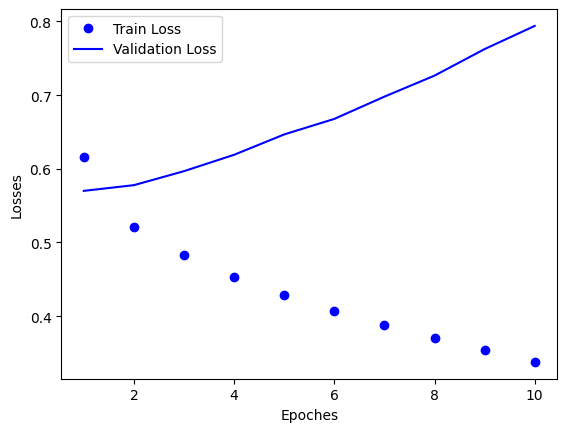

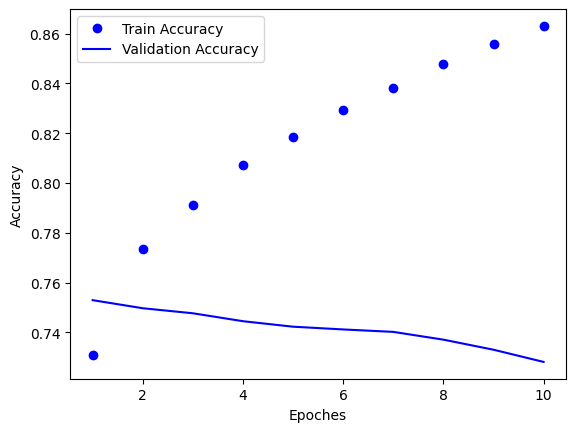

In [32]:
#Plot the graphs



plot_loss(history)
plot_accuracy(history)

In [33]:
# This is a overfitting.

In [34]:
model.evaluate(x_test,y_test)

681/681 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7229 - loss: 0.8167


[0.8166524767875671, 0.7229264378547668]

In [35]:
#The largest class is Rock, with around 85% so a dummy predictor that outputs the most common class would get 58% accuracy.
# Our simple 1-hidden layer NN using multi-hot encoding improves on that nicely !

In [36]:
#So when we use bags of words method, we loose the notion of the order but the order matters.

#Can we do better ? Is there any aspect of the text that we're failing to capture with what we have done so far ?
# Suppose we're trying to predict the sentiment of the movie review that looks something like this.

# Kate Winsel's performance as detective trying to solve a terrible crime in a small Pennsylvania town is anything but disappointing.

# A model looking at each word seperately will get misled by the words terrible and disappointing since they have a negative sentiment if
# looked in isolation.

#However, by looking the words near them ("Terrible crime","anything but disappointing "), you can see that it is actually a positive review.

# Nearby words can thus provide valuable context. And this is useful even for sigle, atomic conceots that happen to be described using multiple
#words e.g. United States
#So how can we make our models more aware of nearby words ?

# We can try bigrams, which use two consecutive words as the level of tokenization.

# For example, the sentence "the cat sat on the mat" becomes:

# Using single words : {"cat", "mat", "on","sat","the"}
# With bigrams : {"the","the cat", "cat", "cat sat","sat on","on","on the","the mat","mat"}

#We don't have to stop with bigrams. We can go to trigrams or higher.

In [8]:
#Text vectorization layer using bigrams

text_vectorization = keras.layers.TextVectorization(
    ngrams = 2,  #default is 1
    output_mode = "multi_hot"
)

In [38]:
text_vectorization.adapt(["the cat sat on the mat."])

In [39]:
text_vectorization.get_vocabulary()

['[UNK]',
 np.str_('the'),
 np.str_('the mat'),
 np.str_('the cat'),
 np.str_('sat on'),
 np.str_('sat'),
 np.str_('on the'),
 np.str_('on'),
 np.str_('mat'),
 np.str_('cat sat'),
 np.str_('cat')]

In [9]:
#Adapt the max_tokens for the biagrams


text_vectorization = keras.layers.TextVectorization(
    ngrams = 2,  #default is 1,
    max_tokens = 20000,
    output_mode = "multi_hot"
)

In [10]:
#Run the SITE process on the training corpus

text_vectorization.adapt(train_df['Lyric'])

In [42]:
#Get the  top most used words here

text_vectorization.get_vocabulary()[:20]

['[UNK]',
 np.str_('the'),
 np.str_('you'),
 np.str_('i'),
 np.str_('to'),
 np.str_('and'),
 np.str_('a'),
 np.str_('me'),
 np.str_('it'),
 np.str_('my'),
 np.str_('in'),
 np.str_('im'),
 np.str_('on'),
 np.str_('your'),
 np.str_('that'),
 np.str_('of'),
 np.str_('all'),
 np.str_('be'),
 np.str_('is'),
 np.str_('we')]

In [43]:
#Get the least used words here

text_vectorization.get_vocabulary()[-20:]

[np.str_('anymore im'),
 np.str_('and into'),
 np.str_('always feel'),
 np.str_('alone if'),
 np.str_('all gonna'),
 np.str_('afford to'),
 np.str_('admit that'),
 np.str_('a hustla'),
 np.str_('a fresh'),
 np.str_('a billion'),
 np.str_('8x'),
 np.str_('44'),
 np.str_('you’re a'),
 np.str_('your mom'),
 np.str_('your god'),
 np.str_('you shot'),
 np.str_('you hell'),
 np.str_('you far'),
 np.str_('ya all'),
 np.str_('x6')]

In [ ]:
X_train = text_vectorization(train_df['Lyric'])
X_val = text_vectorization(validation_df['Lyric'])
X_test = text_vectorization(test_df['Lyric'])



In [2]:
#Now make the model

inputs = keras.Input(shape = (20000,))
x = keras.layers.Dense(8,activation="relu")(inputs)
outputs = keras.layers.Dense(3,activation="softmax")(x)

model = keras.Model(inputs,outputs)

model.summary()

NameError: name 'keras' is not defined

In [1]:
#Train the model
history = model.fit(X_train,y_train,
          validation_data = (X_val, y_val),
          metrics = ['Accuracy'],
          epoches = 10)



NameError: name 'model' is not defined